<h1><center>Laboratorio 10: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Angelo León
- Nombre de alumno 2: Damián De Aguiar


### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/damiatus/labPrograCientifica)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


### Imports

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from xgboost import plot_importance
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
import xgboost as xgb
import shap
import seaborn as sns


In [3]:

# Establecer una semilla global
SEED = 222

# Semilla para la librería random de Python
random.seed(SEED)

# Semilla para NumPy (que afecta a la mayoría de las funciones aleatorias en sklearn y pandas)
np.random.seed(SEED)

# Semilla para XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=SEED)


In [4]:

df = pd.read_csv('./diabetes_data.csv')
df.head()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
def eda(dataframe):
    pd.options.display.max_rows = 200
    pd.set_option('display.max_columns', None)

    print(f"1.- El DataFrame tiene {dataframe.shape[0]} filas y {dataframe.shape[1]} columnas\n")
    print(f"2.- El DataFrame está compuesto por las siguientes columnas: {list(dataframe.columns)}\n")
    
    print("3.- Ejemplos de filas del DataFrame:\n")
    print("Primeras 5 filas:")
    display(dataframe.head(5))
    
    print("Últimas 5 filas:")
    display(dataframe.tail(5))
    
    print("Muestreo aleatorio de 5 filas:")
    display(dataframe.sample(5))
    
    print("4.- Descripción numérica del DataFrame:\n")
    display(dataframe.describe())
    
    print("5.- Cantidad de valores nulos por columna:")
    display(dataframe.isna().sum())
    
    print("6.- Cantidad de valores únicos por columna:")
    unique_values = dataframe.nunique()
    display(unique_values)
    
    print("7.- Tipos de variables por columna:")
    display(dataframe.dtypes)
    
    print("8.- Filas duplicadas en el DataFrame:")
    print(f"{dataframe.duplicated().sum()} filas duplicadas\n")
    
    print("9.- Desglose de variables con a lo más 6 categorías:")
    for column in dataframe.columns:
        if unique_values[column] <= 6:
            print(f"Columna: {column}")
            print(dataframe[column].value_counts())
            print("\n")


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [6]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [7]:
# Inserte su código aquí
#1.1
eda(df)

1.- El DataFrame tiene 70692 filas y 18 columnas

2.- El DataFrame está compuesto por las siguientes columnas: ['Age', 'Sex', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Stroke', 'HighBP', 'Diabetes']

3.- Ejemplos de filas del DataFrame:

Primeras 5 filas:


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


Últimas 5 filas:


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
70687,6.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0
70688,10.0,1.0,1.0,1.0,29.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
70689,13.0,0.0,1.0,1.0,25.0,0.0,1.0,0.0,1.0,0.0,0.0,5.0,15.0,0.0,1.0,0.0,1.0,1.0
70690,11.0,0.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,1.0
70691,9.0,0.0,1.0,1.0,25.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0


Muestreo aleatorio de 5 filas:


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
68036,11.0,1.0,1.0,1.0,33.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
30637,5.0,0.0,1.0,1.0,26.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0
35883,6.0,0.0,0.0,1.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,14.0,0.0,0.0,0.0,0.0,1.0
4581,11.0,1.0,0.0,1.0,23.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
68305,8.0,1.0,0.0,1.0,30.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0


4.- Descripción numérica del DataFrame:



,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


5.- Cantidad de valores nulos por columna:


Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Stroke                  0
HighBP                  0
Diabetes                0
dtype: int64

6.- Cantidad de valores únicos por columna:


Age                     13
Sex                      2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Stroke                   2
HighBP                   2
Diabetes                 2
dtype: int64

7.- Tipos de variables por columna:


Age                     float64
Sex                     float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Stroke                  float64
HighBP                  float64
Diabetes                float64
dtype: object

8.- Filas duplicadas en el DataFrame:
6672 filas duplicadas

9.- Desglose de variables con a lo más 6 categorías:
Columna: Sex
Sex
0.0    38386
1.0    32306
Name: count, dtype: int64


Columna: HighChol
HighChol
1.0    37163
0.0    33529
Name: count, dtype: int64


Columna: CholCheck
CholCheck
1.0    68943
0.0     1749
Name: count, dtype: int64


Columna: Smoker
Smoker
0.0    37094
1.0    33598
Name: count, dtype: int64


Columna: HeartDiseaseorAttack
HeartDiseaseorAttack
0.0    60243
1.0    10449
Name: count, dtype: int64


Columna: PhysActivity
PhysActivity
1.0    49699
0.0    20993
Name: count, dtype: int64


Columna: Fruits
Fruits
1.0    43249
0.0    27443
Name: count, dtype: int64


Columna: Veggies
Veggies
1.0    55760
0.0    14932
Name: count, dtype: int64


Columna: HvyAlcoholConsump
HvyAlcoholConsump
0.0    67672
1.0     3020
Name: count, dtype: int64


Columna: GenHlth
GenHlth
3.0    23427
2.0    19872
4.0    13303
1.0     8282
5.0     5808
Name: count, dtype: int64


Columna

Luego de hacer el eda, vemos que las columnas con vaores no binarios son Age, BMI, GenHlth, MentHlth, y PhysHlth. Procedemos a escalar estas variables para que estén en el mismo rango de 0 a 1 que el resto de variables. Usamos MinMax Scaler para esto. sta decidion tambi´nes porque para XGBoost es emjor usar este tipo de escalamiento.

In [8]:
#1.2
# Cargar el dataset

# Dividir datos en features (X) y target (y)
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

# Crear conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED)

# Definir las columnas que necesitan escalamiento
columns_to_scale = ['Age', 'BMI','GenHlth' ,'MentHlth', 'PhysHlth']

# Crear ColumnTransformer para aplicar MinMaxScaler a las columnas seleccionadas
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(), columns_to_scale)
    ],
    remainder='passthrough',  # Dejar las demás columnas sin cambios
    verbose_feature_names_out=False  # Evita agregar prefijos de transformación a los nombres de las columnas
).set_output(transform="pandas")  # Establece el formato de salida en pandas

# Crear el pipeline con el preprocesamiento y el modelo XGBoost
pipelineXBG = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric="logloss"))
])


In [9]:

# Entrenar el modelo
pipelineXBG.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = pipelineXBG.predict(X_test)
print(classification_report(y_test, y_pred))

/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:48:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11708
         1.0       0.73      0.79      0.76     11856

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



*2.1:* ¿Es acaso un buen predictor de diabetes?  

El modelo parece ser un predictor razonablemente bueno de diabetes, con una precisión y recall equilibrados para ambas clases, alcanzando una precisión general del 75%. Sin embargo, la precisión y el recall en ambos casos rondan el 75%, lo cual es bueno pero no excelente. Esto sugiere que el modelo está capturando patrones relevantes, aunque hay espacio para mejorar su rendimiento, posiblemente con técnicas de optimización del modelo, ajuste de hiperparámetros o la inclusión de más información relevante si está disponible.

*2.2:* ¿Qué buscan explicar las métricas utilizadas?

Las métricas precisión, recall, y F1-score utlizadas explican el rendimiento del modelo en términos de su capacidad para identificar correctamente las clases de interés:

- Precisión: Mide la proporción de verdaderos positivos sobre todos los casos que el modelo predice como positivos. En el contexto de diabetes, indica qué tan preciso es el modelo al predecir que alguien tiene diabetes.  
- Recall: Mide la proporción de verdaderos positivos sobre todos los casos reales de la clase positiva. En este caso, ayuda a ver qué tan bien el modelo está identificando correctamente a todos los pacientes que realmente tienen diabetes.  
- F1-score: Es la media armónica entre precisión y recall. Esta métrica es útil cuando se busca un equilibrio entre precisión y recall, como en este caso, para asegurar que el modelo no solo identifique a los pacientes con diabetes sino que lo haga de forma precisa.  

*2.3:* ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?
  
Las métricas de precisión, recall y F1-score muestran la efectividad del modelo, pero no garantizan que esté usando las mejores características. Para eso, se requieren métodos de interpretabilidad, como SHAP o Permutation Feature Importance, que identifican las características más importantes para la predicción.

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

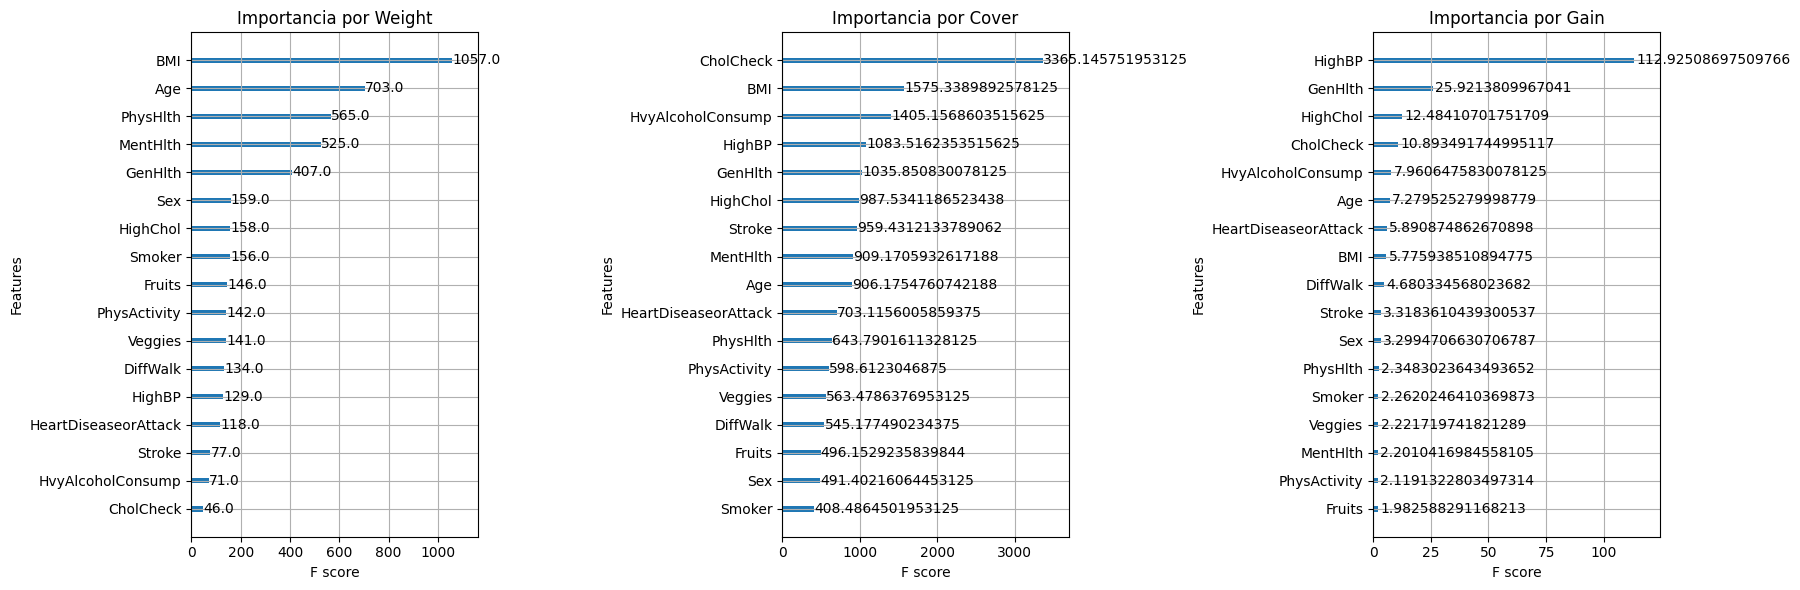

In [10]:
# Inserte su código aquí
#3.1
# Acceder al modelo XGBoost dentro del pipeline
xgb_model = pipelineXBG.named_steps['classifier']  # Asegúrate de usar el nombre correcto del paso

# Plotear la importancia de las features con diferentes métodos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Importancia por "weight"
plot_importance(xgb_model, importance_type='weight', ax=axes[0])
axes[0].set_title('Importancia por Weight')

# Importancia por "cover"
plot_importance(xgb_model, importance_type='cover', ax=axes[1])
axes[1].set_title('Importancia por Cover')

# Importancia por "gain"
plot_importance(xgb_model, importance_type='gain', ax=axes[2])
axes[2].set_title('Importancia por Gain')

plt.tight_layout()
plt.show()

*3.2*  ¿Los resultados obtenidos con los diferentes métodos son compatibles?  

Las métricas de importancia no son iguales porque cada una mide diferentes aspectos de las características:  
- Weight: Cuántas veces una característica se usa en el modelo.
- Cover: Cuántas muestras se ven afectadas por esa característica.
- Gain: Qué tan efectiva es una característica para reducir la impureza del modelo.  

Aunque características como HighBP tienen altos valores en Weight, Cover, y moderado en Gain, otras como Age tienen valores moderados en Cover y Gain, pero no tienen un impacto tan fuerte. Las diferencias se deben a que cada métrica evalúa un aspecto distinto de la importancia predictiva de la característica.

*3.3* ¿Las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método?  

Las métricas weight, cover y gain muestran qué tan relevantes son las características para el modelo, pero no son suficientes para una interpretación completa. Sus debilidades es que no explican las interacciones entre variables ni la causalidad y que no indican el efecto positivo o negativo de una característica. Estas métricas ayudan a entender la importancia, pero para una interpretación más profunda, se deben usar métodos adicionales como SHAP.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

Para implementar un método de permutación que observe la importancia de las features usamos un método permuta los valores de una característica y observa cómo cambia el desempeño del modelo. Cuanto mayor sea la disminución en el desempeño, mayor será la importancia de esa característica.

Desviación estándar de los F1-scores: 0.0000


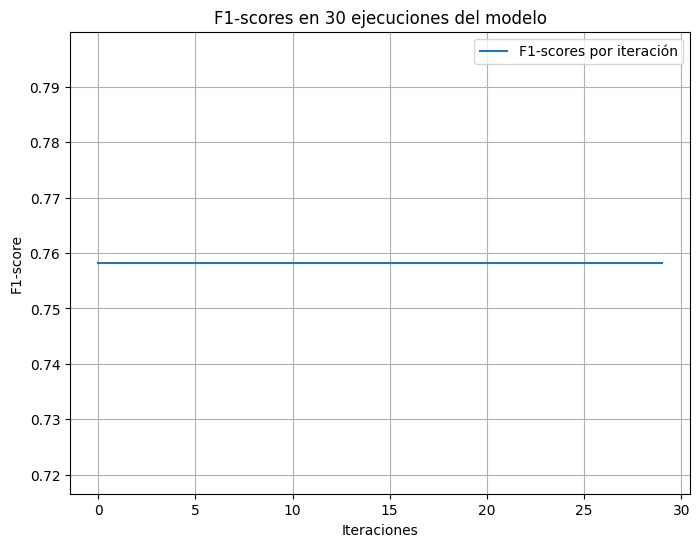

,Feature,Weight,Cover,Gain
11,GenHlth,0.061018,0.061018,0.061018
4,BMI,0.030852,0.030852,0.030852
0,Age,0.027627,0.027627,0.027627
16,HighBP,0.016445,0.016445,0.016445
2,HighChol,0.012558,0.012558,0.012558
3,CholCheck,0.003639,0.003639,0.003639
6,HeartDiseaseorAttack,0.003447,0.003447,0.003447
10,HvyAlcoholConsump,0.003355,0.003355,0.003355
14,DiffWalk,0.002577,0.002577,0.002577
13,PhysHlth,0.002230,0.002230,0.002230


In [ ]:
# Modelo de XGBoost
model = xgb.XGBClassifier(random_state=SEED)

# Dividir los datos
X = df.drop(columns=['Diabetes']) 
y = df['Diabetes']


/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:51:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:51:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:51:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:51:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:51:59] WARNING: /wo

Desviación estándar del F1-score: 0.0032


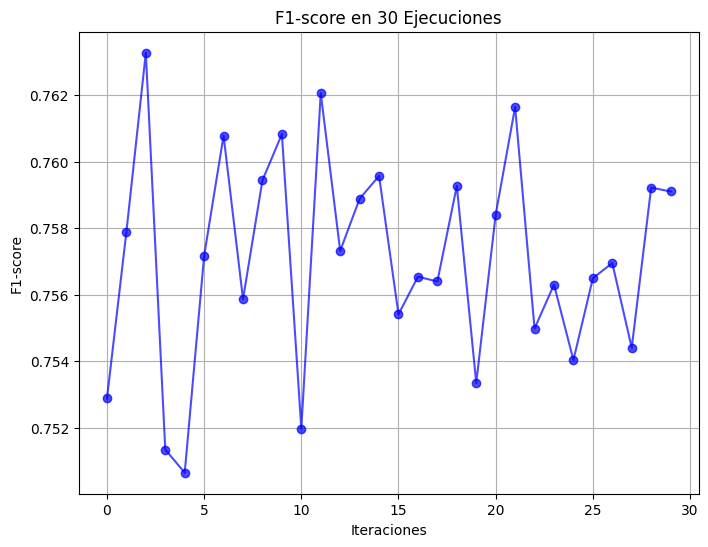

In [12]:
# Inicializar lista para almacenar los F1-scores
f1_scores = []

# Repetir el proceso 30 veces
for _ in range(30):
    # Volver a dividir los datos en entrenamiento y prueba para obtener consistencia
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33) #No usamos semilla ara dividr
    
    # Ajustar el pipeline con el conjunto de entrenamiento
    pipelineXBG.fit(X_train, y_train)
    
    # Realizar predicciones en el conjunto de prueba
    y_pred = pipelineXBG.predict(X_test)
    
    # Calcular el F1-score del modelo
    f1 = f1_score(y_test, y_pred)
    
    # Almacenar el F1-score en la lista
    f1_scores.append(f1)

# Calcular la desviación estándar
std_dev = np.std(f1_scores)

# Mostrar la desviación estándar
print(f'Desviación estándar del F1-score: {std_dev:.4f}')

# Visualizar los resultados con un gráfico
plt.figure(figsize=(8, 6))
plt.plot(f1_scores, marker='o', linestyle='-', color='b', alpha=0.7)
plt.title('F1-score en 30 Ejecuciones')
plt.xlabel('Iteraciones')
plt.ylabel('F1-score')
plt.grid(True)
plt.show()


Utilizamos un bucle para repetir el proceso de entrenamiento y evaluación 30 veces. Cada vez, se hace una nueva división de los datos en conjuntos de entrenamiento y prueba con train_test_split, lo que garantiza que cada ejecución sea independiente.

La desviación estándar nos indica cuán consistentes o variables son los resultados del modelo en las 30 ejecuciones. Si la desviación estándar es baja, significa que el modelo tiene un rendimiento consistente en diferentes particiones de los datos. Si es alta, podría indicar que el modelo es sensible a la partición de los datos, lo que podría señalar que está sobreajustado o que hay una gran variabilidad en los datos que afecta al modelo.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [13]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

Dado que en la oarte 4 se corre el modelo varias veces, volvemos a etrenarlo y a hacer la dicvisón de datos desde cero con la semilla original para que no se alteren los valores

In [15]:
# Dividir datos en features (X) y target (y)
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

# Crear conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED, stratify=y)

# Definir las columnas que necesitan escalamiento
columns_to_scale = ['Age', 'BMI','GenHlth' ,'MentHlth', 'PhysHlth']

# Crear ColumnTransformer para aplicar MinMaxScaler a las columnas seleccionadas
preprocessor2 = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(), columns_to_scale)
    ],
    remainder='passthrough',  # Dejar las demás columnas sin cambios
    verbose_feature_names_out=False  # Evita agregar prefijos de transformación a los nombres de las columnas
).set_output(transform="pandas")  # Establece el formato de salida en pandas

# Crear el pipeline con el preprocesamiento y el modelo XGBoost
pipelineXBG2 = Pipeline([
    ('preprocessor2', preprocessor2),
    ('classifier2', XGBClassifier(use_label_encoder=False, eval_metric="logloss"))
])

# Entrenar el modelo
pipelineXBG2.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = pipelineXBG2.predict(X_test)
print(classification_report(y_test, y_pred))

/home/damiatus/.local/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:52:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



 99%|===================| 23322/23564 [01:33<00:00]        

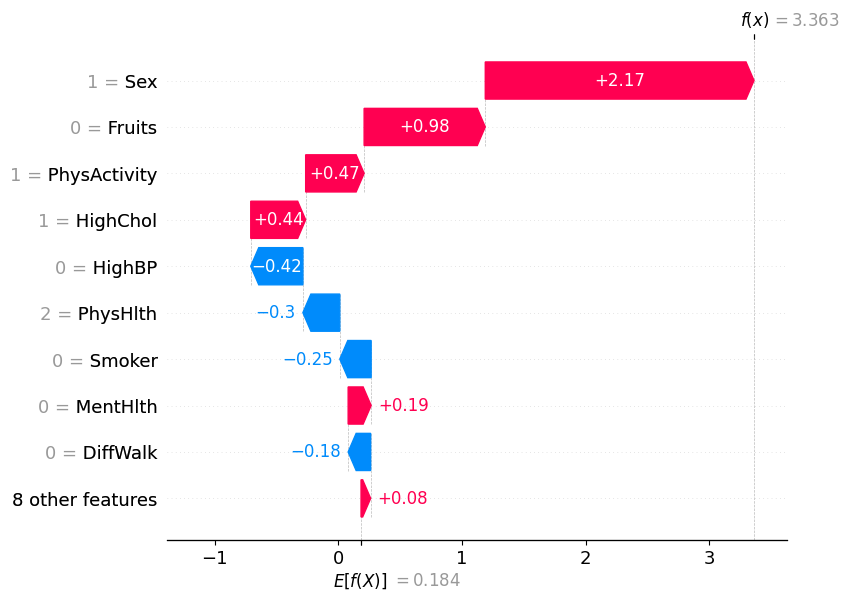

In [16]:

# Crear el modelo con el pipeline ya entrenado
explainer = shap.Explainer(pipelineXBG2.named_steps['classifier2'], X_train)  # Usamos el clasificador entrenado

# Calcular los valores SHAP para todo el conjunto de prueba
shap_values = explainer(X_test)

# Calcular los valores SHAP para la instancia 1 (puedes elegir cualquier otra instancia)
shap_values_instance_1 = shap_values[1,:]  # Valores SHAP para la instancia 1

# Visualizar los valores SHAP para la instancia 1
shap.initjs()
shap.waterfall_plot(shap_values_instance_1)


Acá se aprecia como a nivel indiidual par aun paciente sus caracetíristias influeyn en la posibilidad de tener Diabetes

 *5.1.2* ¿Qué representa cada número en el resultado de los SHAP values?

Cada valor SHAP refleja cómo una característica afecta la predicción para un caso específico (en este caso, para un paciente). Un valor SHAP positivo significa que esa característica ha elevado la probabilidad de que el paciente sea diagnosticado con diabetes, mientras que un valor negativo indica lo contrario, es decir, que reduce la probabilidad de un diagnóstico positivo. Por ejemplo, si el valor SHAP de la característica "Edad" es alto y positivo, implica que, según el modelo, a medida que la edad aumenta, también lo hace la probabilidad de desarrollar diabetes.


  *5.1.3* ¿Es posible atribuir un significado a la positividad/negatividad de cada valor?
  
Los SHAP values muestran cómo cada característica influye en la predicción de un paciente. Un valor positivo indica que la característica aumenta la probabilidad de la clase positiva (diabetes), mientras que un valor negativo la reduce.

Por ejemplo, si la edad tiene un valor positivo, significa que una mayor edad aumenta la probabilidad de diabetes. Si la actividad física tiene un valor negativo, indica que más actividad reduce esa probabilidad.


### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

In [17]:
# Asegúrate de tener los nombres de las características de X_train
X_train.columns  # Si X_train es un DataFrame de pandas

Index(['Age', 'Sex', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk',
       'Stroke', 'HighBP'],
      dtype='object')

In [18]:

# Los valores SHAP para las instancias 1, 9 y 150
shap_values[1,:]  # Valores SHAP para la instancia 1

.values =
array([ 0.00000000e+00,  2.17346147e+00,  4.44110668e-01, -2.57682554e-03,
        0.00000000e+00, -2.53468985e-01, -7.67081949e-04,  4.72754773e-01,
        9.79810928e-01,  4.95505151e-02,  2.64106657e-02,  0.00000000e+00,
        1.85935544e-01, -2.98576895e-01, -1.81952153e-01,  5.07496962e-03,
       -4.21575311e-01])

.base_values =
0.1844365064656813

.data =
array([ 9.,  1.,  1.,  1., 27.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,
        2.,  0.,  0.,  0.])

In [19]:
shap_values[9,:]  # Valores SHAP para la instancia 9

.values =
array([ 0.        , -1.07173339, -0.25235639, -0.01938675,  0.        ,
       -0.62213996, -0.0707683 ,  0.51315684,  0.54619571,  0.06836899,
        0.04266692,  0.        , -0.16945974,  0.17830266,  0.42697723,
       -0.02577598,  0.09769604])

.base_values =
0.1844365064656813

.data =
array([ 9.,  0.,  0.,  1., 42.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,
        0.,  1.,  0.,  1.])

In [20]:
shap_values[150,:]  # Valores SHAP para la instancia 150

.values =
array([ 0.        ,  1.98647863,  0.48864343, -0.01150123,  0.        ,
       -0.25094363, -0.08891059, -1.31782894,  0.44268946, -0.0279963 ,
        0.02373315,  0.        ,  0.14225983, -0.04250514,  0.39958662,
        0.00559801,  0.44717341])

.base_values =
0.1844365064656813

.data =
array([ 6.,  1.,  1.,  1., 32.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,
       30.,  1.,  0.,  1.])

Sabiendo el orden de las fatures analizamos los reusltados

- ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? 

Positivamente: Índice de masa corporal BMI siempre tiene un impacto positivo, indicando que un mayor BMI aumenta la probabilidad de tener diabetes. GenHlth (Salud general) también influye positivamente en algunas instancias.  

Negativamente: HighChol (Colesterol alto) y Stroke (Accidente cerebrovascular) muestran efectos negativos en algunas instancias, indicando que estas variables podrían reducir la probabilidad de diabetes en ciertos casos.

- ¿Existe algún patrón común entre las instancias analizadas? 

Sí, BMI tiene un impacto positivo en todas las instancias. HighChol y Stroke tienen efectos negativos en algunas instancias, pero no de manera consistente.

- ¿Es posible generalizar estas conclusiones a todo el dataset? 

No se deben generalizar los resultados a todo el dataset debido a que las instancias seleccionadas son solo una muestra y podrían no representar la distribución global de los datos. Además, las interacciones entre variables pueden variar.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

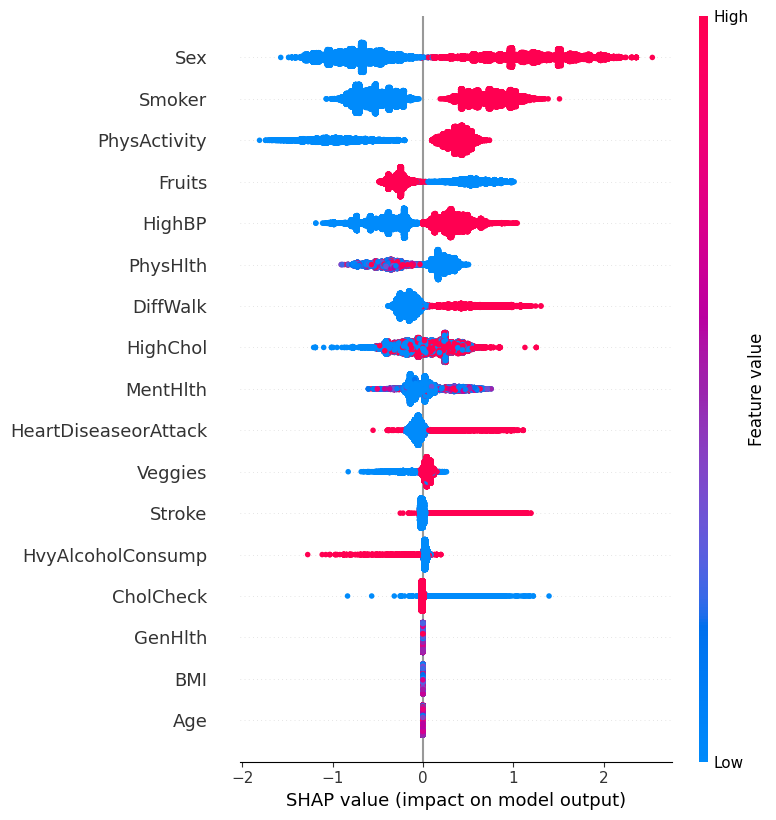

In [21]:
# Crear el modelo con el pipeline ya entrenado
#shap_values = explainer(X_test)

shap.initjs()
shap.summary_plot(shap_values)

Notamos que algunos resultados no coicniden con el conciemito mpedico previo o por la falta de un diccionario la interpretación no es la ideal. Esto se debe a que para PhysActivity, un valor bajo estaría influyendo negativamente en tener diabetes, es decir, que disminuye el riesgo de tener diabetes. Lo mismo pasa con la variable de consumo de alcohol alto que un valor menor influiría en tener diabetes, lo que tampoco se corresponde con el conocimiento científico. El resto de variable parece tener un comportamiento alineado con el conocimiento cinetífico de la enfermedad.


Comparando ambos resultados vemos que a nivel local se sabe cuanto afecta el valor que toma dicha instancia en la prevlencia de diabetes, en cambio al comprar a nivel global se puede entender cómo todo el rango de vlaores de las varoables pueden afectar en tener diabetes, puesto que se sabe como afectan sus valores negaitivos pero tambén positivos, que en ocasiones se pueden comparar distintos como ocurre con Stroke o podrpian tener una relación lineal como en BMI en donde valores positivos y negativos tienen shap values simialres.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

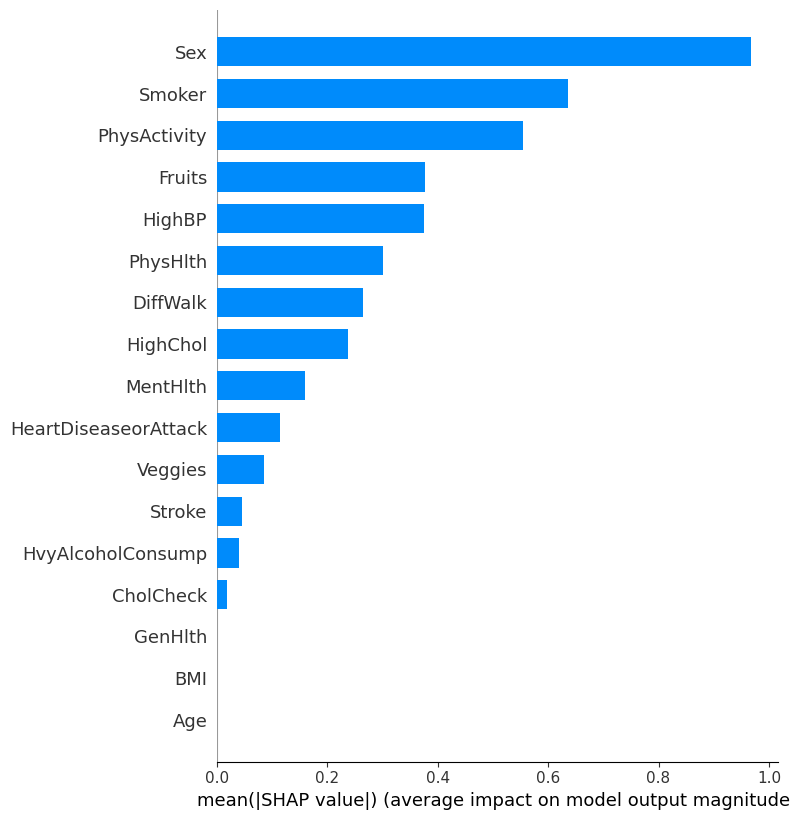

In [22]:
# Visualizar la importancia global de las características
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type="bar")

Tras ver la importancia de las variables vemos que las 5 de mayor importancia son Sex, HighChol, HighBP, BMI y PhysActivity

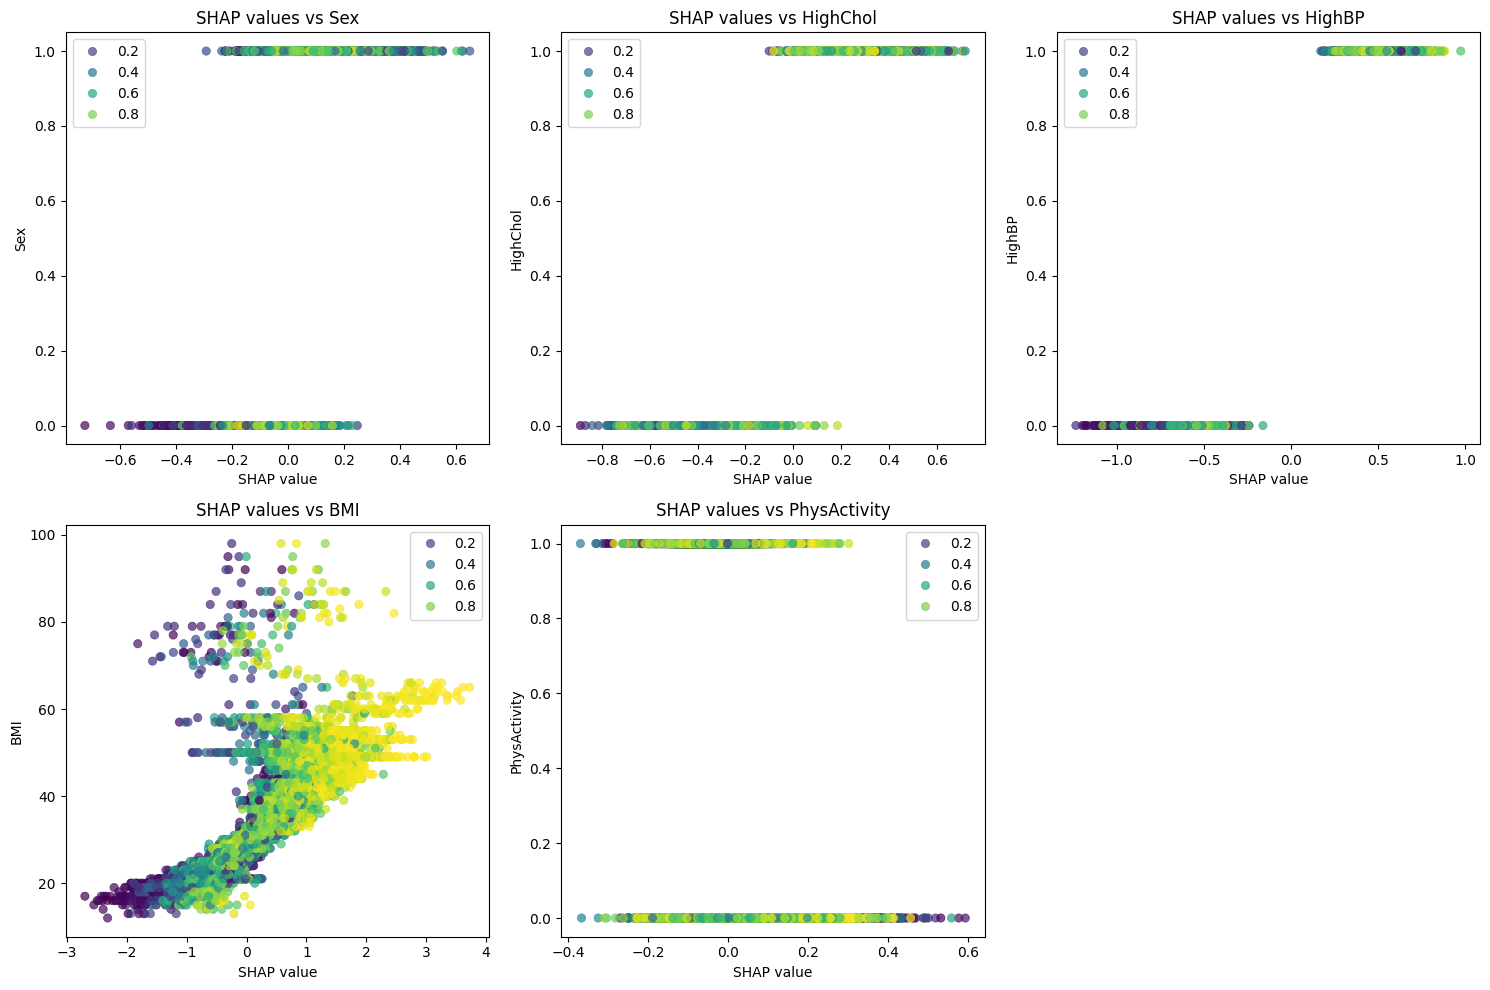

In [27]:

# Definir las características más importantes
features = ['Sex', 'HighChol', 'HighBP', 'BMI', 'PhysActivity']

# Asegúrate de que las columnas del DataFrame X estén en el mismo orden que las del modelo
column_order = model.get_booster().feature_names  # Obtener las características del modelo
X_aligned = X[column_order]  # Reordenar las columnas de X para que coincidan con las del modelo

# Calcular los valores SHAP
explainer = shap.TreeExplainer(model)  # Asegúrate de que el modelo sea compatible con TreeExplainer
shap_values = explainer.shap_values(X_aligned)  # Obtener los valores SHAP para todas las observaciones

# Realizar las predicciones de probabilidad de diabetes
probs = model.predict_proba(X_aligned)[:, 1]  # Probabilidad de la clase positiva (diabetes)

# Crear los gráficos
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    # Obtener los valores SHAP correspondientes a la característica
    shap_feature_values = shap_values[:, X.columns.get_loc(feature)]  # Tomar los valores SHAP para cada feature
    # Crear el gráfico de dispersión con seaborn
    sns.scatterplot(x=shap_feature_values, y=X[feature], hue=probs, palette='viridis', edgecolor=None, alpha=0.7)
    plt.title(f'SHAP values vs {feature}')
    plt.xlabel('SHAP value')
    plt.ylabel(feature)

# Ajustar el layout
plt.tight_layout()
plt.show()

---

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

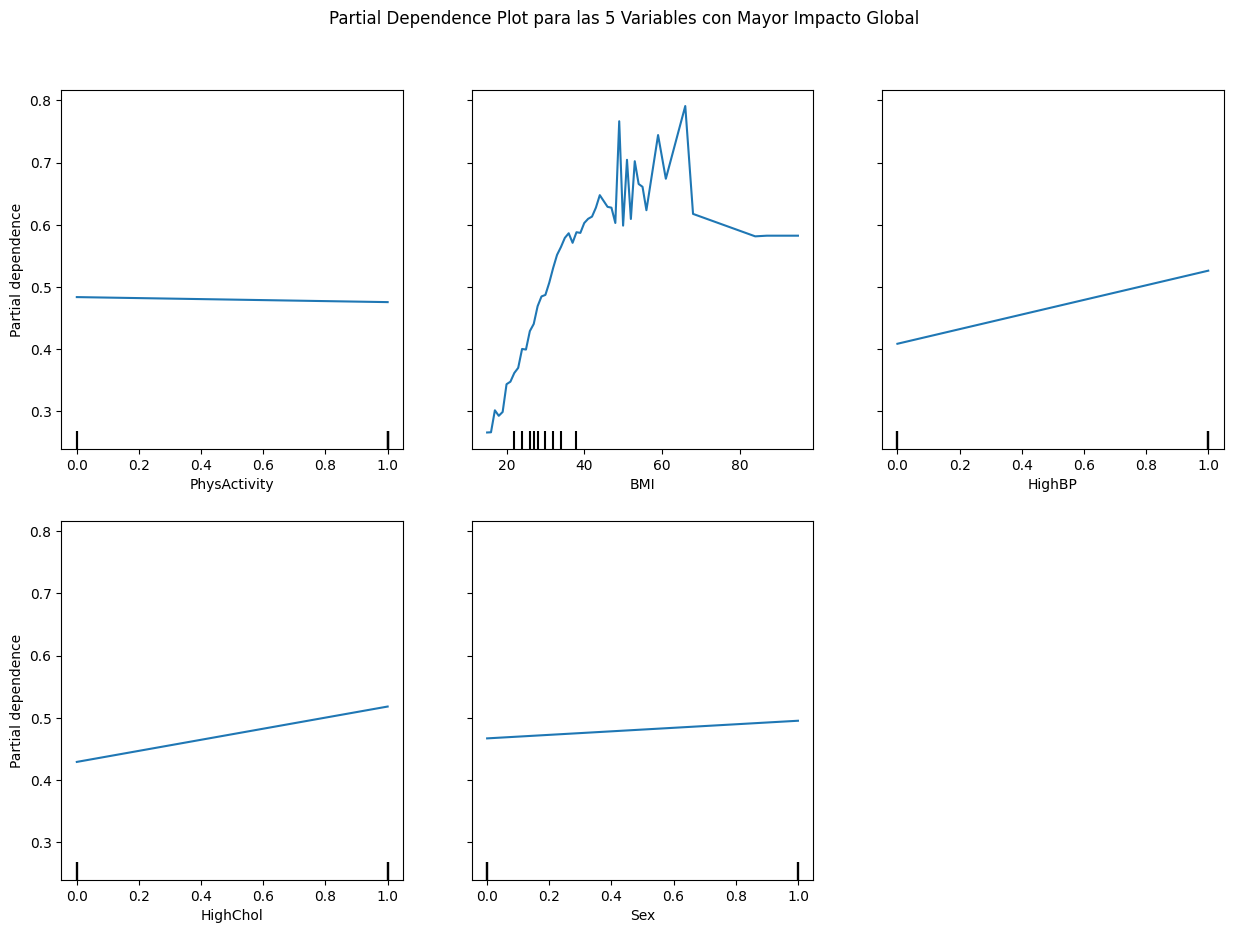

In [ ]:
# Inserte código para generar gráficos PDP aquí
import numpy as np
import pandas as pd
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import matplotlib.pyplot as plt

# Asegúrate de tener X_train y el modelo ya entrenado (model)
# Si X_train es muy grande, crea una submuestra de 1000 observaciones
X_subset = X_train.sample(n=1000, random_state=42)

# Paso 1: Obtener las 5 variables con mayor impacto global a partir de los valores SHAP
# Calcula el valor absoluto promedio de los valores SHAP para cada característica
shap_importance = np.abs(shap_values).mean(axis=0)
# Ordena y selecciona las 5 características más importantes
top_5_features = np.argsort(shap_importance)[-5:]  # Índices de las 5 características más importantes
top_5_feature_names = [X_train.columns[i] for i in top_5_features]

# Paso 2: Generar el gráfico de Partial Dependence Plot para estas 5 variables
fig, ax = plt.subplots(figsize=(15, 10))
PartialDependenceDisplay.from_estimator(model, X_subset, features=top_5_feature_names, ax=ax)

# Mostrar el gráfico
plt.suptitle("Partial Dependence Plot para las 5 Variables con Mayor Impacto Global")
plt.subplots_adjust(top=0.9)  # Ajustar el título
plt.show()


## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo. 
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`. 

In [ ]:
!pip install alibi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 kB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 67.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 85.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.2/313.2 kB 50.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 33.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 84.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 91.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.2/682.2 kB 65.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 42.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from alibi.explainers import AnchorTabular

2023-06-16 03:21:35.062920: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-16 03:21:35.266905: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-06-16 03:21:35.266966: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-06-16 03:21:35.308521: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-06-16 03:21:38.061257: W tensorflow/stream_executor/platform/de

In [ ]:
pipelineXBG.fit(X_train, y_train)

X_train_preprocessed = pipelineXBG.named_steps['preprocessor'].transform(X_train)
X_test_preprocessed = pipelineXBG.named_steps['preprocessor'].transform(X_test)

def predictor_fn(x):
    x_df = pd.DataFrame(x, columns=X_train_preprocessed.columns)
    return pipelineXBG.predict(x_df)

explainer = AnchorTabular(predictor_fn, feature_names=X_train_preprocessed.columns.to_list())
explainer.fit(X_train_preprocessed.to_numpy())

idx = 1000
instance_1000 = X_test_preprocessed.iloc[[idx]].to_numpy()  
explanation_1000 = explainer.explain(instance_1000)
print(f"Explicación para la observación {idx}:")
print(f"Reglas (anclas): {explanation_1000.anchor}")

precision_1000 = explanation_1000.precision if np.isscalar(explanation_1000.precision) else explanation_1000.precision[0]
coverage_1000 = explanation_1000.coverage if np.isscalar(explanation_1000.coverage) else explanation_1000.coverage[0]

print(f"Precisión de las reglas: {precision_1000:.2f}")
print(f"Cobertura de la población: {coverage_1000:.2f}\n")

idx = 3001
instance_3001 = X_test_preprocessed.iloc[[idx]].to_numpy()
explanation_3001 = explainer.explain(instance_3001)
print(f"Explicación para la observación {idx}:")
print(f"Reglas (anclas): {explanation_3001.anchor}")

precision_3001 = explanation_3001.precision if np.isscalar(explanation_3001.precision) else explanation_3001.precision[0]
coverage_3001 = explanation_3001.coverage if np.isscalar(explanation_3001.coverage) else explanation_3001.coverage[0]

print(f"Precisión de las reglas: {precision_3001:.2f}")
print(f"Cobertura de la población: {coverage_3001:.2f}\n")

idx = 5751
instance_5751 = X_test_preprocessed.iloc[[idx]].to_numpy()
explanation_5751 = explainer.explain(instance_5751)
print(f"Explicación para la observación {idx}:")
print(f"Reglas (anclas): {explanation_5751.anchor}")

precision_5751 = explanation_5751.precision if np.isscalar(explanation_5751.precision) else explanation_5751.precision[0]
coverage_5751 = explanation_5751.coverage if np.isscalar(explanation_5751.coverage) else explanation_5751.coverage[0]

print(f"Precisión de las reglas: {precision_5751:.2f}")
print(f"Cobertura de la población: {coverage_5751:.2f}\n")

Al analizar los resultados de las reglas establecidas para las observaciones solicitadas, en el caso de la observación 1000 no se identificaron reglas, lo que significa que no se encontraron condiciones relevantes para explicarla. Esto sugiere que la observación 1000 es muy fácil de clasificar. Además, como la predicción cubre el 100% de la población con condiciones similares, indica que es una observación fácilmente reconocible y generalizable dentro del conjunto de datos.

En cuanto a las observaciones 3001 y 5751, que comparten la misma regla y resultados, se puede concluir que el hecho de tener un nivel bajo de colesterol es un factor determinante en el modelo. Dado que esta regla explica al 48% de la población, sugiere que el conjunto de datos está prácticamente dividido en dos grandes grupos según esta condición, lo que destaca la importancia del colesterol en las predicciones del modelo.

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

 SHAP values es uno de los métodos más útiles para obtener conclusiones claras sobre cómo influyen las variables en las predicciones del modelo. Los valores SHAP proporcionan una visión detallada de la importancia y el impacto de cada característica en la predicción, tanto a nivel global como local. Esto nos permite no solo ver qué características son las más relevantes para la clasificación, sino también cómo varía su impacto en función de los diferentes valores de esas características. Esta información es crucial para comprender el comportamiento del modelo y cómo toma decisiones con respecto a la diabetes.

Por otro lado, en el caso del problema del doctor Simi, los métodos agnósticos locales son probablemente más útiles. Estos métodos permiten analizar cómo se comportan las variables para instancias específicas (como un paciente individual) y cómo afectan su probabilidad de tener diabetes en comparación con otras personas. Este enfoque es relevante para los médicos, ya que les ayuda a tomar decisiones más personalizadas y centradas en cada paciente. Si bien los métodos globales proporcionan una visión general del modelo, los métodos locales permiten una comprensión más precisa de las particularidades de cada caso, lo cual es vital para un diagnóstico adecuado y para un tratamiento individualizado.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://media.tenor.com/ctnq4bhZE3gAAAAC/drsimi-simi.gif)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>